# March 29 temporal replication of the real 2D positive GP

This experiment tests whether the March 8 two-dimensional result persists in a
non-overlapping time window. It fixes the complete experimental design before
examining March 29 outcomes:

- identical geographic 20×20 EASE-cell region;
- identical quadrant boundaries at local x=237.5 km and y=262.5 km;
- identical sensor noise (0.05/0.02 m);
- identical ice/snow length scales (200/100 km);
- identical 7×7 inducing grid and training procedure.

Only the CS2 and IS2 observations are replaced by the March 29 window. The
March 29 region contains 275 paired cells (68.8% coverage), compared with 296
cells (74.0%) for March 8.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

s8=json.load(open('../results/positive_gp_2d_summary.json'))
s29=json.load(open('../results/positive_gp_2d_March29_summary.json'))
d8=np.genfromtxt('../results/positive_gp_2d_blocked_predictions.csv',delimiter=',',names=True,dtype=None,encoding='utf-8')
d29=np.genfromtxt('../results/positive_gp_2d_March29_blocked_predictions.csv',delimiter=',',names=True,dtype=None,encoding='utf-8')
g8=np.genfromtxt('../results/positive_gp_2d_full_grid.csv',delimiter=',',names=True,dtype=None,encoding='utf-8')
g29=np.genfromtxt('../results/positive_gp_2d_March29_full_grid.csv',delimiter=',',names=True,dtype=None,encoding='utf-8')
print('March 8 rows/folds:',s8['region']['rows'],s8['region']['quadrant_fold_sizes'])
print('March 29 rows/folds:',s29['region']['rows'],s29['region']['quadrant_fold_sizes'])


March 8 rows/folds: 296 [78, 81, 79, 58]
March 29 rows/folds: 275 [84, 53, 82, 56]


## Fixed-region temporal comparison


In [2]:
for window,s in [('March 8',s8),('March 29',s29)]:
    print(window)
    for method,key in [('Point + nearest','point_nearest'),('Positive GP','positive_gp')]:
        cs=s[key]['CS2']['RMSE_m']; laser=s[key]['IS2']['RMSE_m']
        print(f'  {method:16s} CS2={cs:.4f} m  IS2={laser:.4f} m')
    for sensor in ['CS2','IS2']:
        baseline=s['point_nearest'][sensor]['RMSE_m']; model=s['positive_gp'][sensor]['RMSE_m']
        print(f'  {sensor} relative reduction={(baseline-model)/baseline*100:.1f}%')


March 8
  Point + nearest  CS2=0.0539 m  IS2=0.0540 m
  Positive GP      CS2=0.0471 m  IS2=0.0452 m
  CS2 relative reduction=12.6%
  IS2 relative reduction=16.2%
March 29
  Point + nearest  CS2=0.0601 m  IS2=0.0557 m
  Positive GP      CS2=0.0598 m  IS2=0.0391 m
  CS2 relative reduction=0.6%
  IS2 relative reduction=29.7%


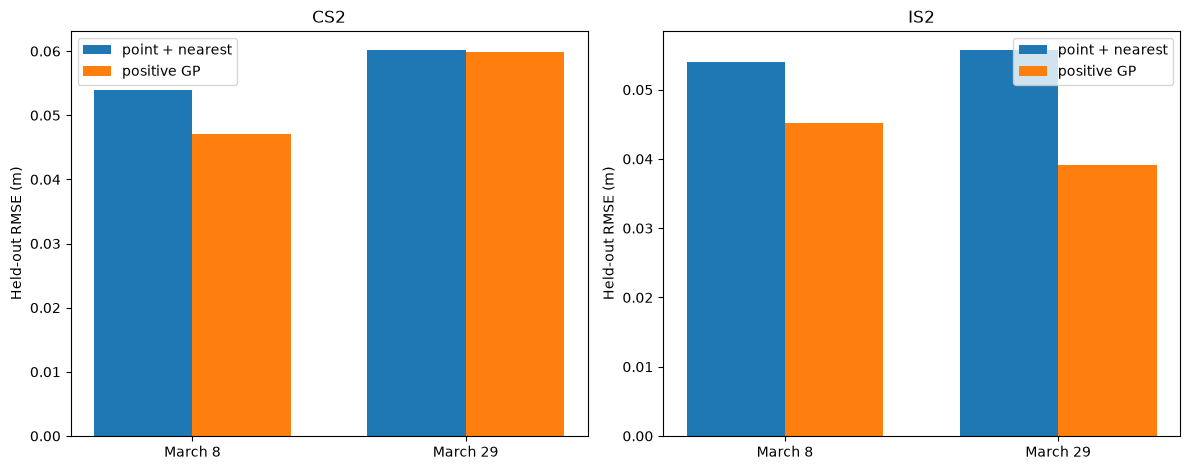

In [3]:
windows=['March 8','March 29']; summaries=[s8,s29]
fig,axs=plt.subplots(1,2,figsize=(12,4.8))
x=np.arange(2);width=.36
for ax,sensor in zip(axs,['CS2','IS2']):
    base=[s['point_nearest'][sensor]['RMSE_m'] for s in summaries]
    gp=[s['positive_gp'][sensor]['RMSE_m'] for s in summaries]
    ax.bar(x-width/2,base,width,label='point + nearest')
    ax.bar(x+width/2,gp,width,label='positive GP')
    ax.set_xticks(x,windows);ax.set_ylabel('Held-out RMSE (m)');ax.set_title(sensor);ax.legend()
plt.tight_layout()


## Held-out error maps


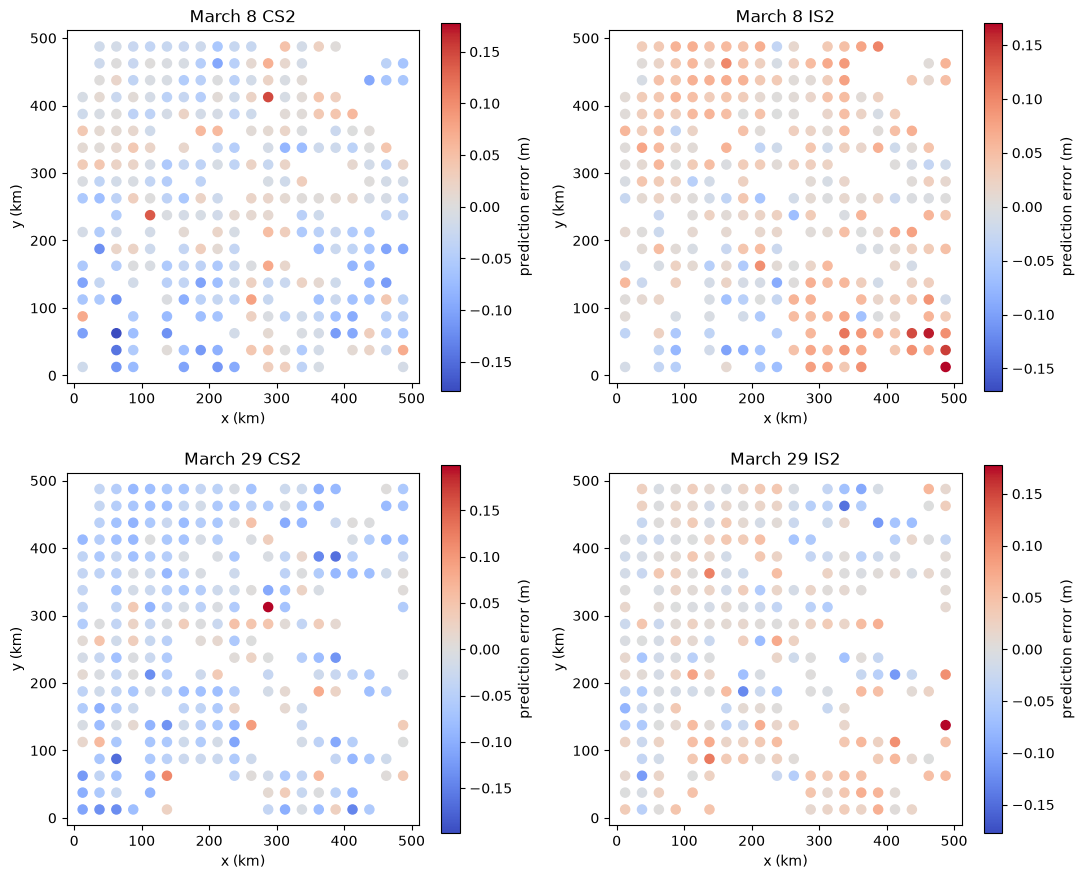

In [4]:
fig,axs=plt.subplots(2,2,figsize=(11,9))
for row,(window,d) in enumerate([('March 8',d8),('March 29',d29)]):
    for col,sensor in enumerate(['cs2','is2']):
        error=d[f'positive_gp_pred_{sensor}_m']-d[f'actual_{sensor}_m']
        limit=max(abs(error.min()),abs(error.max()))
        sc=axs[row,col].scatter(d['local_x_km'],d['local_y_km'],c=error,s=43,cmap='coolwarm',vmin=-limit,vmax=limit)
        plt.colorbar(sc,ax=axs[row,col],label='prediction error (m)')
        axs[row,col].set_title(f'{window} {sensor.upper()}')
        axs[row,col].set_aspect('equal');axs[row,col].set_xlabel('x (km)');axs[row,col].set_ylabel('y (km)')
plt.tight_layout()


## Full-data latent-map comparison (visualization only)


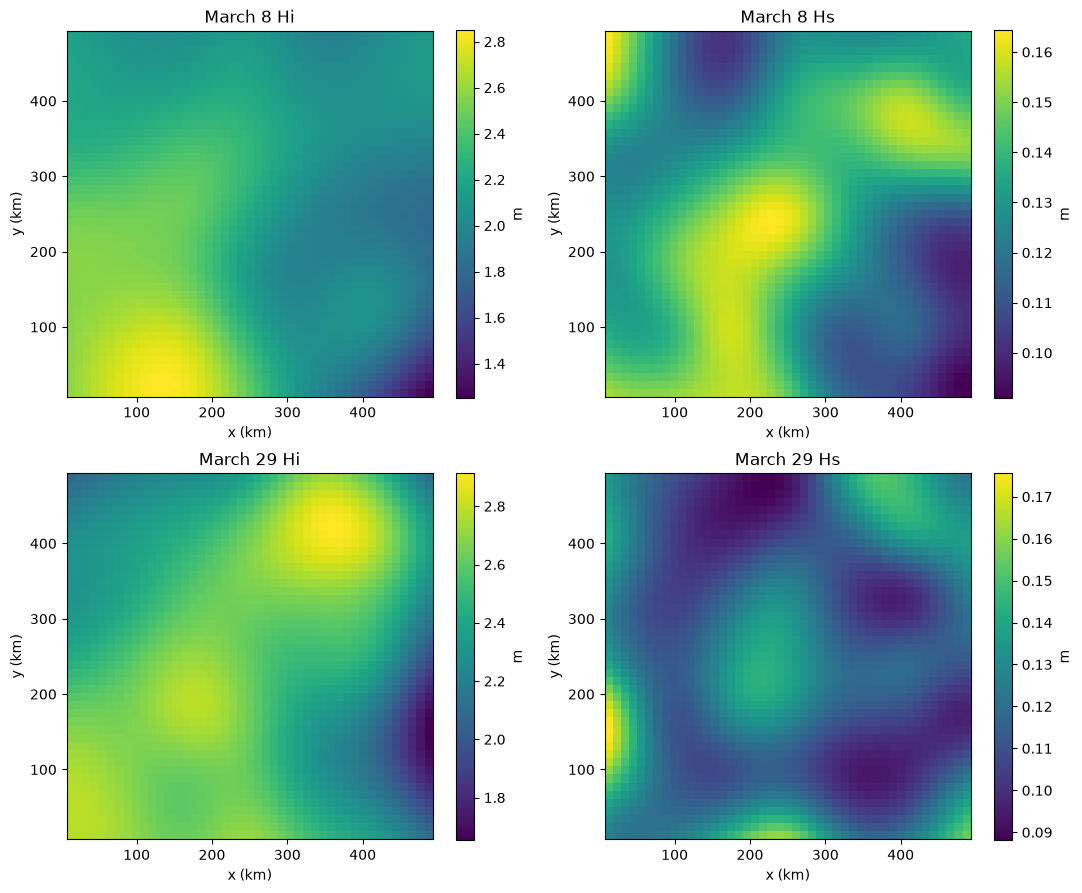

In [5]:
shape=(45,45)
fig,axs=plt.subplots(2,2,figsize=(11,9))
for row,(window,g) in enumerate([('March 8',g8),('March 29',g29)]):
    xx=g['local_x_km'].reshape(shape);yy=g['local_y_km'].reshape(shape)
    for col,latent in enumerate(['Hi','Hs']):
        values=g[f'positive_gp_{latent}_m'].reshape(shape)
        im=axs[row,col].pcolormesh(xx,yy,values,shading='auto',cmap='viridis')
        plt.colorbar(im,ax=axs[row,col],label='m')
        axs[row,col].set_title(f'{window} {latent}')
        axs[row,col].set_aspect('equal');axs[row,col].set_xlabel('x (km)');axs[row,col].set_ylabel('y (km)')
plt.tight_layout()


## Evidence-based conclusion

- March 8: the positive GP reduces CS2 RMSE by 12.6% and IS2 RMSE by 16.2%.
- March 29: the IS2 reduction strengthens to 29.7%, while the CS2 reduction is
  only 0.6% (0.06013 to 0.05980 m).
- Both windows produce zero negative ice-thickness and snow-depth estimates.
- The non-overlapping replication therefore supports a robust 2D improvement
  for IS2, but not a strong general claim for CS2. For CS2 the model is clearly
  better in March 8 and essentially tied with the baseline in March 29.
- March 29 CS2 has a −0.037 m model bias, suggesting that the frozen sensor
  noise or penetration assumptions do not transfer perfectly through time.

The defensible dissertation claim is that the positive multi-output GP scales
to real 2D data and provides repeatable gains for laser freeboard while
preserving physical latent constraints. Radar-freeboard improvement is
window-dependent. This qualified result is stronger than reporting only the
successful March 8 region and avoids overclaiming temporal robustness.
